# 02 — Training Replicas

For each window pair (A, B) this notebook:

1. Tunes XGBoost hyperparameters **per window** using Optuna with TimeSeriesSplit, optimising PR-AUC.
2. Trains **R XGBoost replicas** per window using stratified bootstrap sampling + different random seeds, with early stopping on a chronological validation tail.
3. Evaluates on the common evaluation slice E_{A,B} (replica-averaged predictions, PR-AUC and ROC-AUC).
4. Identifies the **flagged set** F_{A,B} as the top K_FRAC fraction of eval instances ranked by max(p_hat_A, p_hat_B).

**Input:** `data/processed/`, `data/windows/window_config.json` 
**Output per pair:** `data/models/pair_{pid:02d}/` 
- `replicas_A/model_r{r}.joblib` (R models)
- `replicas_B/model_r{r}.joblib` (R models)
- `replicas_A/training_log_r{r}.csv`, `replicas_B/training_log_r{r}.csv` — per-replica eval-metric curve
- `replicas_A/seeds_r{r}.json`, `replicas_B/seeds_r{r}.json` — exact bootstrap/model seeds for reproducibility
- `hparams_A.json`, `hparams_B.json` — tuned hyperparameters used for all R replicas of that window
- `reference_scaler.joblib` — StandardScaler fit on window A's numeric features only (for covariate drift / LIME in later notebooks; NOT used by XGBoost)
- `predictions.npz` — see schema below

**`predictions.npz` schema:**
| Key | Shape | Meaning |
|---|---|---|
| `preds_A` | `(R, n_eval)` | per-replica positive-class probability, window A |
| `preds_B` | `(R, n_eval)` | per-replica positive-class probability, window B |
| `p_hat_A` | `(n_eval,)` | replica-averaged probability, window A |
| `p_hat_B` | `(n_eval,)` | replica-averaged probability, window B |
| `flagged_idx` | `(n_flagged,)` | **local** positions within `idx_eval` of instances in the flagged set |
| `Y_eval` | `(n_eval,)` | true labels on the evaluation slice |
| `pr_auc_A` | scalar | average precision of `p_hat_A` |
| `pr_auc_B` | scalar | average precision of `p_hat_B` |
| `roc_auc_A` | scalar | ROC-AUC of `p_hat_A` |
| `roc_auc_B` | scalar | ROC-AUC of `p_hat_B` |
| `per_replica_pr_auc_A` | `(R,)` | PR-AUC of each individual replica, window A |
| `per_replica_pr_auc_B` | `(R,)` | PR-AUC of each individual replica, window B |

---

**Replica design:** Each replica differs by:
1. A different random seed for the learning algorithm.
2. A stratified bootstrap sample of the training window (preserves class ratio).

Bootstrap seed and model seed are logged separately per replica.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.5 MB/s eta 0:00:00


In [13]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
 
optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKSPACE  = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR   = WORKSPACE / 'data' / 'processed'
WIN_DIR    = WORKSPACE / 'data' / 'windows'
MODEL_DIR  = WORKSPACE / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Silence Optuna's default per-trial logging (we'll log study-level summaries ourselves)
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Fixed XGBoost parameters (not tuned; per-window params come from Optuna) ─
XGB_FIXED = dict(
    tree_method  = 'hist',
    eval_metric  = 'aucpr',
    verbosity    = 0,
    n_jobs       = -1,
    objective    = 'binary:logistic',
)

# ── Tuning configuration ─────────────────────────────────────────────────
N_TRIALS       = 50    # Optuna trials per window
CV_N_SPLITS    = 3     # TimeSeriesSplit folds inside each window
ES_ROUNDS      = 50    # early stopping rounds
MAX_BOOST_RND  = 2000  # hard cap on n_estimators (early stopping will usually trigger first)
VAL_TAIL_FRAC  = 0.15  # fraction of bootstrap (chronological tail) used as replica-level ES set

print('Imports OK')

Imports OK


In [21]:
# ── Load processed data ────────────────────────────────────────────────
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
X    = X_df.values.astype(np.float32)
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feat_names = json.load(f)
num_cols = feat_names['num']                              # 113 numeric feature names
num_col_idx = [X_df.columns.get_loc(c) for c in num_cols] # positions in X (for reference scaler)

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R       = config['parameters']['R']
K_FRAC  = config['parameters']['K_FRAC']
pairs   = config['pairs']

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'R={R}, K_FRAC={K_FRAC}, {len(pairs)} window pairs')
print(f'Numeric feature count: {len(num_cols)}')

X: (160057, 119), Y: (160057,)
R=8, K_FRAC=0.1, 2 window pairs
Numeric feature count: 113


In [22]:
# ═════════════════════════════════════════════════════════════════════════
# Helper functions
# ═════════════════════════════════════════════════════════════════════════
def stratified_bootstrap(idx: np.ndarray, Y: np.ndarray, seed: int) -> np.ndarray:
    """Stratified bootstrap: sample with replacement, preserving class ratio.

    Returns an array of row indices (into the global X/Y) with length equal to len(idx),
    containing the same number of positives and negatives as the input slice.
    """
    rng = np.random.default_rng(seed)
    pos = idx[Y[idx] == 1]
    neg = idx[Y[idx] == 0]
    boot_pos = rng.choice(pos, size=len(pos), replace=True)
    boot_neg = rng.choice(neg, size=len(neg), replace=True)
    out = np.concatenate([boot_pos, boot_neg])
    rng.shuffle(out)  # mix positives and negatives so the tail split is not all-positive
    return out


def _build_model(params: dict, seed: int, early_stopping_rounds: int = None) -> XGBClassifier:
    """Construct an XGBClassifier with fixed settings + tuned params + a given seed.

    early_stopping_rounds is passed to the constructor (required by XGBoost >= 2.0).
    """
    full = {**XGB_FIXED, **params, 'random_state': seed, 'n_estimators': MAX_BOOST_RND}
    if early_stopping_rounds is not None:
        full['early_stopping_rounds'] = early_stopping_rounds
    return XGBClassifier(**full)


def tune_hyperparameters(window_idx: np.ndarray,
                         X_all: np.ndarray,
                         Y_all: np.ndarray,
                         study_seed: int,
                         n_trials: int = N_TRIALS) -> dict:
    """Optuna tuning of XGBoost hyperparameters on the given training window.

    Uses TimeSeriesSplit(CV_N_SPLITS) over the chronological order of window_idx.
    The objective is mean PR-AUC across folds. Early stopping on each fold uses the
    fold's own validation set. Returns the best-trial parameter dict.
    """
    X_win = X_all[window_idx]
    Y_win = Y_all[window_idx]

    tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS)

    def objective(trial: optuna.Trial) -> float:
        params = {
            'max_depth':        trial.suggest_int('max_depth', 4, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'gamma':            trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        }
        pr_aucs = []
        for fold, (tr, va) in enumerate(tscv.split(X_win)):
            model = _build_model(params, seed=study_seed + fold,
                                 early_stopping_rounds=ES_ROUNDS)
            model.fit(
                X_win[tr], Y_win[tr],
                eval_set=[(X_win[va], Y_win[va])],
                verbose=False,
            )
            p = model.predict_proba(X_win[va])[:, 1]
            pr_aucs.append(average_precision_score(Y_win[va], p))
        return float(np.mean(pr_aucs))

    sampler = TPESampler(seed=study_seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return dict(study.best_trial.params)


def train_replica_with_es(X_train: np.ndarray,
                          Y_train: np.ndarray,
                          params: dict,
                          boot_seed: int,
                          model_seed: int,
                          val_tail_frac: float = VAL_TAIL_FRAC):
    """Train one XGBoost replica on a bootstrap sample, with early stopping on a tail split.

    Holds out the final `val_tail_frac` fraction of the (shuffled) bootstrap as the
    early-stopping validation set. Returns (model, training_log_df).
    """
    n = len(X_train)
    n_val = max(int(np.ceil(n * val_tail_frac)), 1)
    X_tr, X_va = X_train[:-n_val], X_train[-n_val:]
    Y_tr, Y_va = Y_train[:-n_val], Y_train[-n_val:]

    model = _build_model(params, seed=model_seed, early_stopping_rounds=ES_ROUNDS)
    model.fit(
        X_tr, Y_tr,
        eval_set=[(X_va, Y_va)],
        verbose=False,
    )
    evals_result = model.evals_result()
    val_curve = evals_result.get('validation_0', {}).get('aucpr', [])
    training_log = pd.DataFrame({
        'iteration': np.arange(1, len(val_curve) + 1),
        'val_aucpr': val_curve,
    })
    return model, training_log


def predict_proba_pos(model: XGBClassifier, X_in: np.ndarray) -> np.ndarray:
    """Return probability of positive class (uses best iteration if early stopping triggered)."""
    return model.predict_proba(X_in)[:, 1]


def compute_flagged_topk(p_hat_A: np.ndarray,
                         p_hat_B: np.ndarray,
                         k_frac: float) -> np.ndarray:
    """Top-K% flagged set: the top k_frac fraction of eval instances ranked by
    max(p_hat_A, p_hat_B). Returns local indices (positions within the eval slice).

    This replaces the previous fixed-threshold definition |{x : p_A >= tau or p_B >= tau}|.
    The size is fixed at round(k_frac * n_eval), making F_{A,B} comparable across pairs.
    """
    assert p_hat_A.shape == p_hat_B.shape
    n = len(p_hat_A)
    k = max(int(round(k_frac * n)), 1)
    score = np.maximum(p_hat_A, p_hat_B)
    topk_unsorted = np.argpartition(-score, k - 1)[:k]
    return np.sort(topk_unsorted)


print('Helpers defined.')

Helpers defined.


In [ ]:
# ═════════════════════════════════════════════════════════════════════════
# Main training loop — one iteration per window pair
# ═════════════════════════════════════════════════════════════════════════

SEED_BASE = 42

performance_log = []

for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    pred_file = pair_dir / 'predictions.npz'

    # Skip-if-done: load cached metrics and move on
    if pred_file.exists():
        data = np.load(pred_file)
        if not all(k in data.files for k in ('roc_auc_A', 'roc_auc_B')):
            print(f'Pair {pid:02d}: stale predictions.npz (missing roc_auc keys) — re-running.')
        else:
            print(f'Pair {pid:02d}: already done, skipping.')
            performance_log.append({
                'pair_id':   pid,
                'pr_auc_A':  float(data['pr_auc_A']),
                'pr_auc_B':  float(data['pr_auc_B']),
                'roc_auc_A': float(data['roc_auc_A']),
                'roc_auc_B': float(data['roc_auc_B']),
                'n_flagged': int(data['flagged_idx'].shape[0]),
            })
            continue

    print(f'\n── Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]}  '
          f'eval={p["eval_start_label"]}→{p["eval_end_label"]}  '
          f'|A|={p["n_train_A"]:,} |B|={p["n_train_B"]:,} |eval|={p["n_eval"]:,} ──')

    idx_A    = np.array(p['idx_A'],    dtype=np.int64)
    idx_B    = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    # Safety check: no leakage across windows/eval
    assert len(set(idx_A.tolist())    & set(idx_eval.tolist())) == 0, 'idx_A and idx_eval overlap!'
    assert len(set(idx_B.tolist())    & set(idx_eval.tolist())) == 0, 'idx_B and idx_eval overlap!'

    X_eval = X[idx_eval]
    Y_eval = Y[idx_eval]

    pair_dir.mkdir(parents=True, exist_ok=True)
    dir_A = pair_dir / 'replicas_A'
    dir_B = pair_dir / 'replicas_B'
    dir_A.mkdir(exist_ok=True)
    dir_B.mkdir(exist_ok=True)

    # ── Fit reference scaler on W_k numeric features (for covariate drift / LIME later) ──
    # Not used by XGBoost. Numeric-only: binary features are passed through unchanged.
    ref_scaler = StandardScaler()
    ref_scaler.fit(X[idx_A][:, num_col_idx])
    joblib.dump(ref_scaler, pair_dir / 'reference_scaler.joblib')

    # ── Tune hyperparameters per window ──
    print('  Tuning window A ...')
    hparams_A = tune_hyperparameters(idx_A, X, Y, study_seed=SEED_BASE + pid * 10 + 1)
    with open(pair_dir / 'hparams_A.json', 'w') as f:
        json.dump(hparams_A, f, indent=2)
    print(f'    best A params: {hparams_A}')

    print('  Tuning window B ...')
    hparams_B = tune_hyperparameters(idx_B, X, Y, study_seed=SEED_BASE + pid * 10 + 2)
    with open(pair_dir / 'hparams_B.json', 'w') as f:
        json.dump(hparams_B, f, indent=2)
    print(f'    best B params: {hparams_B}')

    # ── Train R replicas for window A ──
    preds_A = np.zeros((R, len(idx_eval)), dtype=np.float32)
    per_rep_pr_auc_A = np.zeros(R, dtype=np.float32)
    for r in range(R):
        boot_seed  = SEED_BASE + pid * 10_000 + r * 2          # A-bootstrap seeds are even
        model_seed = SEED_BASE + pid * 10_000 + r * 2 + 1      # A-model seeds are odd
        boot_idx   = stratified_bootstrap(idx_A, Y, seed=boot_seed)

        X_tr = X[boot_idx]
        Y_tr = Y[boot_idx]
        model, training_log = train_replica_with_es(X_tr, Y_tr, hparams_A, boot_seed, model_seed)

        preds_A[r] = predict_proba_pos(model, X_eval)
        per_rep_pr_auc_A[r] = average_precision_score(Y_eval, preds_A[r])

        joblib.dump(model, dir_A / f'model_r{r}.joblib', compress=3)
        training_log.to_csv(dir_A / f'training_log_r{r}.csv', index=False)
        with open(dir_A / f'seeds_r{r}.json', 'w') as f:
            json.dump({'bootstrap_seed': int(boot_seed),
                       'model_seed':     int(model_seed)}, f, indent=2)
        print(f'  A replica {r}: PR-AUC = {per_rep_pr_auc_A[r]:.4f}')

    # ── Train R replicas for window B ──
    preds_B = np.zeros((R, len(idx_eval)), dtype=np.float32)
    per_rep_pr_auc_B = np.zeros(R, dtype=np.float32)
    for r in range(R):
        boot_seed  = SEED_BASE + pid * 10_000 + 5_000 + r * 2      # B-bootstrap seeds (offset 5000)
        model_seed = SEED_BASE + pid * 10_000 + 5_000 + r * 2 + 1
        boot_idx   = stratified_bootstrap(idx_B, Y, seed=boot_seed)

        X_tr = X[boot_idx]
        Y_tr = Y[boot_idx]
        model, training_log = train_replica_with_es(X_tr, Y_tr, hparams_B, boot_seed, model_seed)

        preds_B[r] = predict_proba_pos(model, X_eval)
        per_rep_pr_auc_B[r] = average_precision_score(Y_eval, preds_B[r])

        joblib.dump(model, dir_B / f'model_r{r}.joblib', compress=3)
        training_log.to_csv(dir_B / f'training_log_r{r}.csv', index=False)
        with open(dir_B / f'seeds_r{r}.json', 'w') as f:
            json.dump({'bootstrap_seed': int(boot_seed),
                       'model_seed':     int(model_seed)}, f, indent=2)
        print(f'  B replica {r}: PR-AUC = {per_rep_pr_auc_B[r]:.4f}')

    # ── Replica-averaged predictions and flagged set ──
    p_hat_A = preds_A.mean(axis=0)
    p_hat_B = preds_B.mean(axis=0)
    flagged_local_idx = compute_flagged_topk(p_hat_A, p_hat_B, K_FRAC)

    pr_auc_A  = average_precision_score(Y_eval, p_hat_A)
    pr_auc_B  = average_precision_score(Y_eval, p_hat_B)
    roc_auc_A = roc_auc_score(Y_eval, p_hat_A)
    roc_auc_B = roc_auc_score(Y_eval, p_hat_B)

    print(f'  Averaged: PR-AUC A = {pr_auc_A:.4f}, PR-AUC B = {pr_auc_B:.4f}')
    print(f'            ROC-AUC A = {roc_auc_A:.4f}, ROC-AUC B = {roc_auc_B:.4f}')
    print(f'  Flagged (top {K_FRAC:.0%}): {flagged_local_idx.shape[0]:,} / {len(idx_eval):,}')

    # ── Save predictions NPZ ──
    np.savez_compressed(
        pred_file,
        preds_A              = preds_A,
        preds_B              = preds_B,
        p_hat_A              = p_hat_A,
        p_hat_B              = p_hat_B,
        flagged_idx          = flagged_local_idx,
        Y_eval               = Y_eval,
        pr_auc_A             = np.float32(pr_auc_A),
        pr_auc_B             = np.float32(pr_auc_B),
        roc_auc_A            = np.float32(roc_auc_A),
        roc_auc_B            = np.float32(roc_auc_B),
        per_replica_pr_auc_A = per_rep_pr_auc_A,
        per_replica_pr_auc_B = per_rep_pr_auc_B,
    )

    performance_log.append({
        'pair_id':   pid,
        'pr_auc_A':  pr_auc_A,
        'pr_auc_B':  pr_auc_B,
        'roc_auc_A': roc_auc_A,
        'roc_auc_B': roc_auc_B,
        'n_flagged': flagged_local_idx.shape[0],
    })

print('\n✓ All window pairs processed.')

Pair 00: stale predictions.npz (missing roc_auc keys) — re-running.

── Pair 00: A_end=2013-04-01  B_end=2013-04-08  eval=2013-04-15→2013-04-22  |A|=98,241 |B|=101,740 |eval|=51,585 ──
  Tuning window A ...
    best A params: {'max_depth': 5, 'learning_rate': 0.03839730945174753, 'min_child_weight': 1.601788851015164, 'subsample': 0.8262224905670426, 'colsample_bytree': 0.9488188985172153, 'reg_alpha': 0.02196244452729709, 'reg_lambda': 0.003072053115261744, 'gamma': 2.9198800328646475}
  Tuning window B ...
    best B params: {'max_depth': 5, 'learning_rate': 0.04622225165828686, 'min_child_weight': 13.254556101349419, 'subsample': 0.6595392252176876, 'colsample_bytree': 0.8251799832635893, 'reg_alpha': 0.004331327823536606, 'reg_lambda': 0.004915635888840602, 'gamma': 0.0026067047538162664}
  A replica 0: PR-AUC = 0.3855
  A replica 1: PR-AUC = 0.3947
  A replica 2: PR-AUC = 0.3919
  A replica 3: PR-AUC = 0.3859
  A replica 4: PR-AUC = 0.3940
  A replica 5: PR-AUC = 0.3921
  A replic

 pair_id  pr_auc_A  pr_auc_B  roc_auc_A  roc_auc_B  n_flagged
       0  0.390434  0.389035   0.555293   0.551717       5158
       1  0.395478  0.430659   0.547820   0.567840       4867

Mean PR-AUC  A: 0.3930   B: 0.4098
Mean ROC-AUC A: 0.5516   B: 0.5598


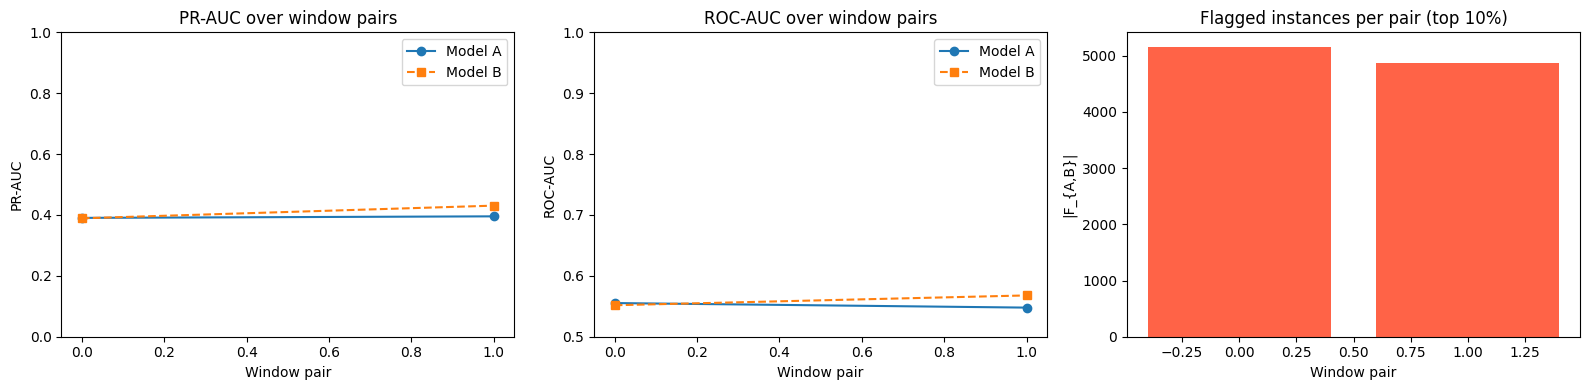

In [24]:
perf_df = pd.DataFrame(performance_log)
print(perf_df.to_string(index=False))
print(f'\nMean PR-AUC  A: {perf_df["pr_auc_A"].mean():.4f}   B: {perf_df["pr_auc_B"].mean():.4f}')
print(f'Mean ROC-AUC A: {perf_df["roc_auc_A"].mean():.4f}   B: {perf_df["roc_auc_B"].mean():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_A'], 'o-', label='Model A')
axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_B'], 's--', label='Model B')
axes[0].set_title('PR-AUC over window pairs')
axes[0].set_xlabel('Window pair')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_A'], 'o-', label='Model A')
axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_B'], 's--', label='Model B')
axes[1].set_title('ROC-AUC over window pairs')
axes[1].set_xlabel('Window pair')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].set_ylim(0.5, 1)

axes[2].bar(perf_df['pair_id'], perf_df['n_flagged'], color='tomato')
axes[2].set_title(f'Flagged instances per pair (top {int(K_FRAC*100)}%)')
axes[2].set_xlabel('Window pair')
axes[2].set_ylabel('|F_{A,B}|')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'performance_summary.png', dpi=120)
plt.show()

In [25]:
# Save performance log
perf_df.to_csv(MODEL_DIR / 'performance_log.csv', index=False)
print('Performance log saved.')

Performance log saved.
